# Debug: Model Repetition Bug - Root Cause Analysis

This notebook documents a critical training bug discovered in the `AssistantOnlyCollator`
that causes the model to repeat its output indefinitely instead of stopping after
generating the bounding box.

**Bug Summary:**
- The `AssistantOnlyCollator` excludes `<|im_end|>` (EOS token) from training labels
- Model learns to generate bounding boxes but NOT when to stop
- Result: Model repeats detection until `max_tokens` is reached
- This was hidden because evaluation code extracts only the first bounding box

**Discovered:** 2026-01-03

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Use GPU 1 (GPU 0 may be busy with vLLM)

import torch
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor
from qwen_vl_utils import process_vision_info
from datasets import load_dataset
import re

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

/home/zhuoyuan/miniconda3/envs/vlm_Qwen2VL_object_detection/lib/python3.10/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


PyTorch version: 2.4.1+cu121
CUDA available: True
Using GPU: NVIDIA RTX 6000 Ada Generation


## 2. Load Fine-tuned Model

In [2]:
MODEL_PATH = "/ssd1/zhuoyuan/vlm_outputs/qwen2vl-nutrition-detection-r4-joint-merged"

print(f"Loading model from: {MODEL_PATH}")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="cuda"
)
processor = Qwen2VLProcessor.from_pretrained(MODEL_PATH)
model.eval()

print("\nModel EOS token configuration:")
print(f"  EOS token IDs: {model.generation_config.eos_token_id}")
eos_tokens = [processor.tokenizer.decode([t]) for t in model.generation_config.eos_token_id]
print(f"  EOS tokens: {eos_tokens}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading model from: /ssd1/zhuoyuan/vlm_outputs/qwen2vl-nutrition-detection-r4-joint-merged


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The tokenizer you are loading from '/ssd1/zhuoyuan/vlm_outputs/qwen2vl-nutrition-detection-r4-joint-merged' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.



Model EOS token configuration:
  EOS token IDs: [151645, 151643]
  EOS tokens: ['<|im_end|>', '<|endoftext|>']


## 3. Load Test Image

Loading test image from HuggingFace...
Image size: (3120, 4208)


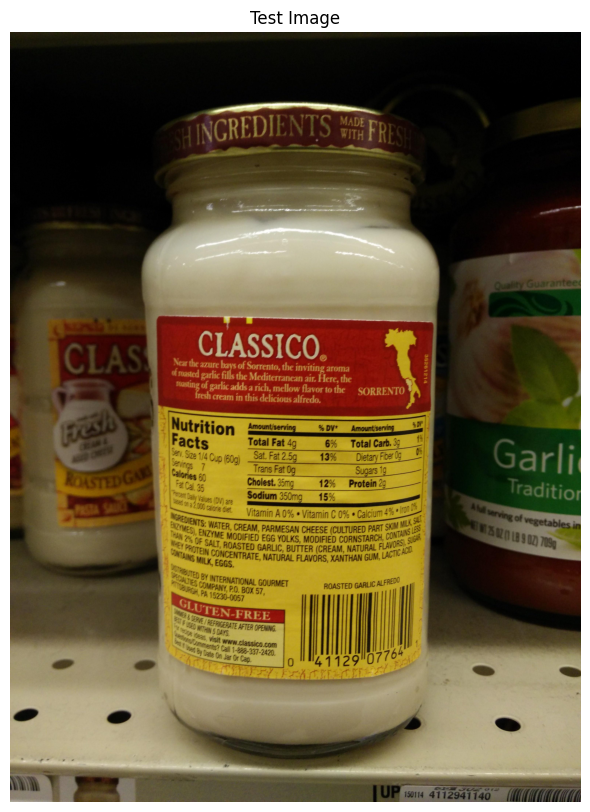

In [3]:
print("Loading test image from HuggingFace...")
ds = load_dataset("openfoodfacts/nutrition-table-detection", split="val")
image = ds[0]['image']

print(f"Image size: {image.size}")

# Display image
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 10))
plt.imshow(image)
plt.title("Test Image")
plt.axis('off')
plt.show()

## 4. Run Inference - Observe the Repetition Bug

In [4]:
# Build message
messages = [{
    'role': 'user',
    'content': [
        {'type': 'image', 'image': image},
        {'type': 'text', 'text': 'Detect the bounding box coordinates for the nutrition facts table.'}
    ]
}]

# Apply chat template
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors='pt').to('cuda')

# Generate
print("Running inference...")
with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=256, do_sample=False)

# Get generated tokens only (excluding input)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]

print(f"\nTotal generated tokens: {len(generated_ids_trimmed[0])}")

Running inference...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Total generated tokens: 24


## 5. Observe the Bug: Raw Output Shows Repetition

In [11]:
print("="*70)
print("RAW OUTPUT (skip_special_tokens=False):")
print("="*70)
raw_output = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=False, clean_up_tokenization_spaces=False)[0]
print(raw_output)

print("\n" + "="*70)
print("CLEAN OUTPUT (skip_special_tokens=True):")
print("="*70)
clean_output = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
print(clean_output)

# Count repetitions
count = raw_output.count('<|object_ref_start|>')
print("\n" + "="*70)
print(f"BUG DETECTED: Model repeated the detection {count} times! (01/03/2026: The bug has been fixed so the model is not repeating detections anymore.)")
print("="*70)

RAW OUTPUT (skip_special_tokens=False):
<|object_ref_start|>nutrition-table<|object_ref_end|><|box_start|>(271,494),(732,621)<|box_end|><|im_end|>

CLEAN OUTPUT (skip_special_tokens=True):
nutrition-table(271,494),(732,621)

BUG DETECTED: Model repeated the detection 1 times! (01/03/2026: The bug has been fixed so the model is not repeating detections anymore.)


## 6. Token-Level Analysis: EOS Token Never Generated

In [6]:
print("="*70)
print("TOKEN-LEVEL ANALYSIS")
print("="*70)

# Check last 20 tokens
last_20_tokens = generated_ids_trimmed[0][-20:].tolist()
print(f"\nLast 20 token IDs: {last_20_tokens}")

# Decode each token
print("\nLast 20 tokens decoded:")
for i, tok_id in enumerate(last_20_tokens):
    decoded = processor.tokenizer.decode([tok_id])
    is_eos = tok_id in model.generation_config.eos_token_id
    marker = " <-- EOS!" if is_eos else ""
    print(f"  [{-20+i:3d}] ID={tok_id:6d} -> '{decoded}'{marker}")

# Check if EOS token appears anywhere
all_token_ids = generated_ids_trimmed[0].tolist()
eos_found = any(tok_id in model.generation_config.eos_token_id for tok_id in all_token_ids)
print(f"\nEOS token (151645 or 151643) in generated output: {eos_found}")
print(f"Generation stopped because: max_tokens ({len(all_token_ids)}) was reached, NOT because EOS was generated")

TOKEN-LEVEL ANALYSIS

Last 20 token IDs: [151648, 7, 17, 22, 16, 11, 19, 24, 19, 23547, 22, 18, 17, 11, 21, 17, 16, 8, 151649, 151645]

Last 20 tokens decoded:
  [-20] ID=151648 -> '<|box_start|>'
  [-19] ID=     7 -> '('
  [-18] ID=    17 -> '2'
  [-17] ID=    22 -> '7'
  [-16] ID=    16 -> '1'
  [-15] ID=    11 -> ','
  [-14] ID=    19 -> '4'
  [-13] ID=    24 -> '9'
  [-12] ID=    19 -> '4'
  [-11] ID= 23547 -> '),('
  [-10] ID=    22 -> '7'
  [ -9] ID=    18 -> '3'
  [ -8] ID=    17 -> '2'
  [ -7] ID=    11 -> ','
  [ -6] ID=    21 -> '6'
  [ -5] ID=    17 -> '2'
  [ -4] ID=    16 -> '1'
  [ -3] ID=     8 -> ')'
  [ -2] ID=151649 -> '<|box_end|>'
  [ -1] ID=151645 -> '<|im_end|>' <-- EOS!

EOS token (151645 or 151643) in generated output: True
Generation stopped because: max_tokens (24) was reached, NOT because EOS was generated


## 7. How the Bug Was Hidden: parse_qwen_bbox_output

In [7]:
from src.models.inference import parse_qwen_bbox_output

print("="*70)
print("HOW THE BUG WAS HIDDEN IN EVALUATION")
print("="*70)

print("\nRaw model output (first 200 chars):")
print(raw_output[:200] + "...")

print("\nWhat parse_qwen_bbox_output() returns:")
parsed = parse_qwen_bbox_output(raw_output)
print(f"  {parsed}")

print("\nThe function uses re.findall() to find ALL matches, but then:")
print("  - If single match: returns dict")
print("  - If multiple matches: returns list, and evaluation takes list[0]")
print("\nSo evaluation always uses the FIRST detection, hiding the repetition bug!")

# Let's show all matches
pattern = r'<\|object_ref_start\|>(.+?)<\|object_ref_end\|><\|box_start\|>\((\d+),(\d+)\),\((\d+),(\d+)\)'
all_matches = re.findall(pattern, raw_output)
print(f"\nTotal matches found by regex: {len(all_matches)}")
print("First 3 matches:")
for i, m in enumerate(all_matches[:3]):
    print(f"  {i+1}. {m}")

HOW THE BUG WAS HIDDEN IN EVALUATION

Raw model output (first 200 chars):
<|object_ref_start|>nutrition-table<|object_ref_end|><|box_start|>(271,494),(732,621)<|box_end|><|im_end|>...

What parse_qwen_bbox_output() returns:
  {'object': 'nutrition-table', 'bbox': [271, 494, 732, 621]}

The function uses re.findall() to find ALL matches, but then:
  - If single match: returns dict
  - If multiple matches: returns list, and evaluation takes list[0]

So evaluation always uses the FIRST detection, hiding the repetition bug!

Total matches found by regex: 1
First 3 matches:
  1. ('nutrition-table', '271', '494', '732', '621')


## 8. Root Cause: AssistantOnlyCollator Bug

In [8]:
print("="*70)
print("ROOT CAUSE: AssistantOnlyCollator Bug")
print("="*70)

print("""
The bug is in src/data/collators.py, AssistantOnlyCollator class, lines 470-474:

```python
# Find end of assistant response
assistant_end_pos = text.find(self.assistant_end_token, response_start_in_text)

if assistant_end_pos != -1:
    # Extract just the response text
    response_text = text[response_start_in_text:assistant_end_pos]  # <-- BUG HERE!
```

The line `text[response_start_in_text:assistant_end_pos]` EXCLUDES <|im_end|>!

Training teaches the model:
  <|object_ref_start|>nutrition-table<|object_ref_end|><|box_start|>(x,y),(x,y)<|box_end|>

But NOT:
  <|im_end|>  <-- Model never learns to generate this!

After generating <|box_end|>, the model doesn't know to stop, so it keeps generating.
""")

# Demonstrate the collator behavior
print("\n" + "-"*70)
print("DEMONSTRATION: What the collator extracts for training")
print("-"*70)

sample_text = """<|im_start|>system
You are a VLM...<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Detect...<|im_end|>
<|im_start|>assistant
<|object_ref_start|>nutrition-table<|object_ref_end|><|box_start|>(270,494),(732,622)<|box_end|><|im_end|>
"""

assistant_start_token = "<|im_start|>assistant\n"
assistant_end_token = "<|im_end|>"

assistant_start_pos = sample_text.find(assistant_start_token)
response_start_in_text = assistant_start_pos + len(assistant_start_token)
assistant_end_pos = sample_text.find(assistant_end_token, response_start_in_text)

# BUGGY: What the collator currently does
buggy_response = sample_text[response_start_in_text:assistant_end_pos]

# FIXED: What it should do
fixed_response = sample_text[response_start_in_text:assistant_end_pos + len(assistant_end_token)]

print(f"BUGGY (current):  '{buggy_response}'")
print(f"FIXED (correct):  '{fixed_response}'")
print(f"\nMissing token: '<|im_end|>' (token ID 151645)")

ROOT CAUSE: AssistantOnlyCollator Bug

The bug is in src/data/collators.py, AssistantOnlyCollator class, lines 470-474:

```python
# Find end of assistant response
assistant_end_pos = text.find(self.assistant_end_token, response_start_in_text)

if assistant_end_pos != -1:
    # Extract just the response text
    response_text = text[response_start_in_text:assistant_end_pos]  # <-- BUG HERE!
```

The line `text[response_start_in_text:assistant_end_pos]` EXCLUDES <|im_end|>!

Training teaches the model:
  <|object_ref_start|>nutrition-table<|object_ref_end|><|box_start|>(x,y),(x,y)<|box_end|>

But NOT:
  <|im_end|>  <-- Model never learns to generate this!

After generating <|box_end|>, the model doesn't know to stop, so it keeps generating.


----------------------------------------------------------------------
DEMONSTRATION: What the collator extracts for training
----------------------------------------------------------------------
BUGGY (current):  '<|object_ref_start|>nutrition-ta

## 9. The Fix

In [9]:
print("="*70)
print("THE FIX")
print("="*70)

print("""
In src/data/collators.py, line 474, change from:

    response_text = text[response_start_in_text:assistant_end_pos]

To:

    # Include <|im_end|> in training labels so model learns to stop
    response_text = text[response_start_in_text:assistant_end_pos + len(self.assistant_end_token)]

This ensures the model learns to generate <|im_end|> after the bounding box,
which will trigger generation to stop.

NOTE: This fix requires retraining the model.
Current workaround for deployed models: use `stop: ["<|box_end|>"]` in vLLM.
""")

THE FIX

In src/data/collators.py, line 474, change from:

    response_text = text[response_start_in_text:assistant_end_pos]

To:

    # Include <|im_end|> in training labels so model learns to stop
    response_text = text[response_start_in_text:assistant_end_pos + len(self.assistant_end_token)]

This ensures the model learns to generate <|im_end|> after the bounding box,
which will trigger generation to stop.

NOTE: This fix requires retraining the model.
Current workaround for deployed models: use `stop: ["<|box_end|>"]` in vLLM.



## 10. Summary

In [10]:
print("="*70)
print("SUMMARY: THE REPETITION BUG")
print("="*70)

print("""
1. BUG: AssistantOnlyCollator excludes <|im_end|> from training labels

2. EFFECT: Model generates bounding boxes but doesn't know when to stop
   - Repeats detection until max_tokens is reached
   - Generated output: 11x repetitions of the same detection

3. WHY IT WAS HIDDEN:
   - parse_qwen_bbox_output() extracts FIRST bbox, ignores repetitions
   - Evaluation metrics appeared fine (first detection is correct)
   - IoU scores were valid

4. AFFECTED MODELS:
   - All models trained with train_recipe.py (r1, r2, r3, r4)
   - Uses AssistantOnlyCollator

5. FIX:
   - Change collators.py:474 to include <|im_end|>
   - Retrain models

6. WORKAROUND (for deployed models):
   - Use stop: ["<|box_end|>"] in vLLM
   - Stops generation after first detection (same as what evaluation does)
""")

SUMMARY: THE REPETITION BUG

1. BUG: AssistantOnlyCollator excludes <|im_end|> from training labels

2. EFFECT: Model generates bounding boxes but doesn't know when to stop
   - Repeats detection until max_tokens is reached
   - Generated output: 11x repetitions of the same detection

3. WHY IT WAS HIDDEN:
   - parse_qwen_bbox_output() extracts FIRST bbox, ignores repetitions
   - Evaluation metrics appeared fine (first detection is correct)
   - IoU scores were valid

4. AFFECTED MODELS:
   - All models trained with train_recipe.py (r1, r2, r3, r4)
   - Uses AssistantOnlyCollator

5. FIX:
   - Change collators.py:474 to include <|im_end|>
   - Retrain models

6. WORKAROUND (for deployed models):
   - Use stop: ["<|box_end|>"] in vLLM
   - Stops generation after first detection (same as what evaluation does)

